In [5]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score
from stellar_classification.models.trees import SimpleRandomForest

#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))
import stellar_classification as sc

In [6]:
#importo i dati 

data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, target_col='class', test_size=0.2, val_ratio=0.25,
    random_state=42, apply_outlier_removal=True
)
class_names = list(label_encoder.classes_)

Outliers removed: 9,400 rows  (90,600 remain)


In [8]:
#train su random forest ed extra trees
models = sc.train_trees_with_tuning(X_train, y_train, X_val, y_val, n_iter=5, cv=3)
rf_model = models['Random Forest']
et_model = models['Extra Trees']

Random Forest best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}
  [Train] Acc=99.71%  F1=0.9971
  [Val] Acc=97.46%  F1=0.9567
Extra Trees best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': None}
  [Train] Acc=98.39%  F1=0.9839
  [Val] Acc=96.79%  F1=0.9492


In [9]:
#evaluate test set
rf_metrics = sc.evaluate_test_set(y_test, rf_model.predict(X_test), 'Random Forest')
et_metrics = sc.evaluate_test_set(y_test, et_model.predict(X_test), 'Extra Trees')

sc.print_metrics(rf_metrics)
sc.print_metrics(et_metrics)


Random Forest:
  Accuracy  : 97.47%
  Precision: 0.9545
  Recall   : 0.9599
  F1       : 0.9572
  Confusion Matrix:
[[11562   226    36]
 [  195  1799     0]
 [    1     0  4301]]

Extra Trees:
  Accuracy  : 96.91%
  Precision: 0.9468
  Recall   : 0.9584
  F1       : 0.9524
  Confusion Matrix:
[[11450   222   152]
 [  184  1808     2]
 [    0     0  4302]]


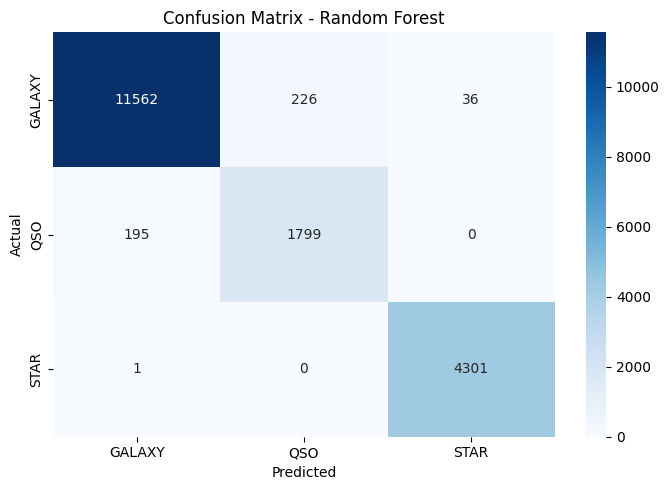

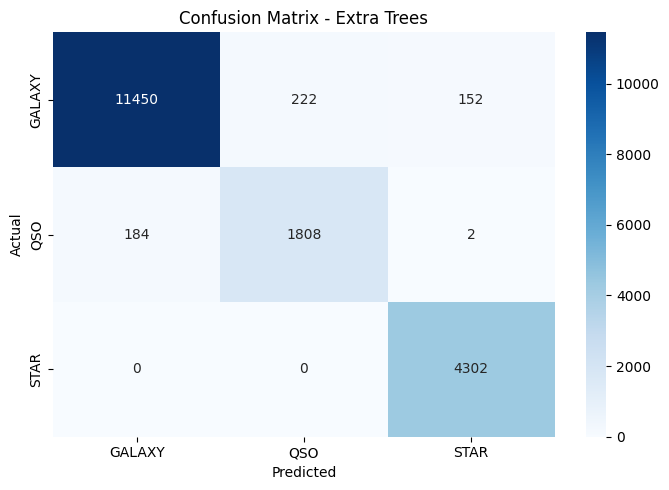

In [10]:
#matrici di confusione per i due modelli 

sc.plot_confusion_matrix(rf_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Random Forest')
sc.plot_confusion_matrix(et_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Extra Trees')

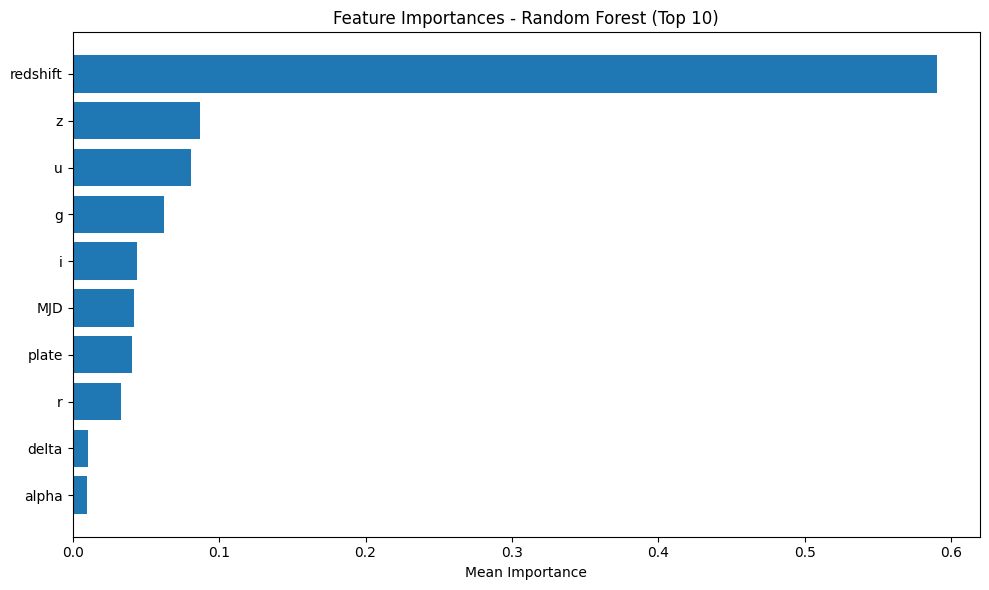

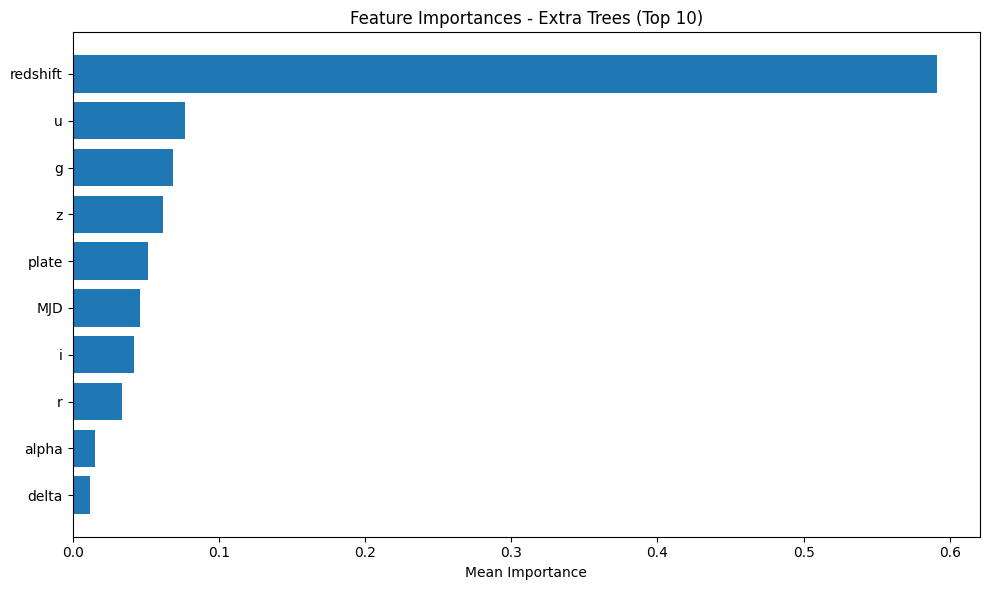

In [11]:
#faccio la fetaure importance interna alle random forest e extra trees

for name, model in [('Random Forest', rf_model), ('Extra Trees', et_model)]:
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    sc.plot_permutation_importance(imp, top_n=10, title=f'Feature Importances - {name}')

In [18]:
#vedo le feature in ordine di importanza 
imp_order = pd.Series(rf_model.feature_importances_, index=feature_names)\
              .sort_values(ascending=False).index.tolist()
print( 'in ordine le feature piu importanti sono:')
for i, a in enumerate( imp_order):
    print( f'{i} -> {a}')

in ordine le feature piu importanti sono:
0 -> redshift
1 -> z
2 -> u
3 -> g
4 -> i
5 -> MJD
6 -> plate
7 -> r
8 -> delta
9 -> alpha
